In [5]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.pyplot as plt
import altair as als
import seaborn as sns
import folium

# 1. Limpieza de datos

### Cargar el Dataframe en Colab
Durante este paso se realiza el cargue del dataset de wage11 bajo el nombre de data_source

In [6]:
# from google.colab import files
# uploaded = files.upload()

In [7]:
# Propósito: ubicar la ruta efectiva del dataset y validar su existencia antes de cargarlo.
df = pd.read_excel("dataset.xlsx")
df.head()

,ID,Genero,Etnia,Municipio,Departamento,Region,Lote,cohorte,Estrato,Fecha de Nacimiento,...,Cabeza de familia,Temas de interés,Sistemas Operativos,Estado,Puntaje,Nivel,Fecha Realización,Institución,Grupo,Fecha de registro
0,1,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,NaN,Estrato 3,1990-07-13,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
1,2,Hombre,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",SABANALARGA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 1,2005-12-10,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
2,3,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 3,1992-02-17,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Pre-Inscrito,93.33,1.0,2024-10-17 16:22:57,NaN,NaN,2024-10-15 03:52:02
3,4,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,NaN,Estrato 2,1996-04-28,...,NaN,Fortalecer mis conocimientos,Windows,Importado,NaN,NaN,NaT,NaN,NaN,NaT
4,5,Hombre,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 1,1.0,Estrato 1,1998-12-02,...,NaN,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Certificado,46.67,1.0,2024-10-24 08:00:00,NaN,R6-L1-PG-B-V-JN-G186,2024-10-24 08:00:00


### Normalización de nombres de columnas
En este paso, realizamos una normalizacion a los nombres de las columnas, con el fin de utilizar nombres mas descriptivos de acuerdo al dato que estan proporcionando

In [8]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('¿', '')
df.columns = df.columns.str.replace('?', '')
df.columns = df.columns.str.replace('á', 'a')
df.columns = df.columns.str.replace('é', 'e')
df.columns = df.columns.str.replace('í', 'i')
df.columns = df.columns.str.replace('ó', 'o')
df.columns = df.columns.str.replace('ú', 'u')

df.columns

Index(['id', 'genero', 'etnia', 'municipio', 'departamento', 'region', 'lote',
       'cohorte', 'estrato', 'fecha_de_nacimiento', 'discapacidad',
       'nivel_academico', 'programa', 'jornada', 'modalidad', 'es_campesino',
       'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
       'tiene_14_horas_a_la_semana',
       'motivo_por_el_que_no_dispone_de_14_horas', 'como_se_entero',
       'trabaja_actualmente', 'empresa_donde_trabaja', 'cargo_que_desempeña',
       'salario', 'actividad_actual', 'rol_actual', 'cabeza_de_familia',
       'temas_de_interes', 'sistemas_operativos', 'estado', 'puntaje', 'nivel',
       'fecha_realizacion', 'institucion', 'grupo', 'fecha_de_registro'],
      dtype='str')

### Eliminacion de Duplicados

#### Eliminación de duplicados por id.

Primero se realiza una busqueda de duplicados a traves del subset definido. Cuyo unico valor esta dado por el id.

In [9]:
duplicados_totales = df.duplicated(subset=['id']).sum()
print("Duplicados encontrados:", duplicados_totales)

df_cleaned = df.drop_duplicates(subset=['id'])
df_cleaned.describe()

Duplicados encontrados: 230


,id,cohorte,fecha_de_nacimiento,motivo_por_el_que_no_dispone_de_14_horas,cabeza_de_familia,puntaje,nivel,fecha_realizacion,fecha_de_registro
count,10707.000000,1325.000000,10373,0.0,279.0,2798.000000,2794.000000,2799,4359
mean,6726.646586,2.680755,1994-07-01 01:15:39.477489,NaN,1.0,67.450940,1.044739,2024-11-16 20:47:22.286888,2024-10-10 09:24:19.839183
min,1.000000,1.000000,1913-09-19 00:00:00,NaN,1.0,0.000000,1.000000,2024-08-01 00:00:00,2024-08-06 18:18:09
25%,2721.500000,1.000000,1989-11-19 00:00:00,NaN,1.0,50.000000,1.000000,2024-08-22 11:28:57,2024-08-12 10:03:32
50%,5489.000000,1.000000,1997-07-09 00:00:00,NaN,1.0,73.330000,1.000000,2024-09-09 17:04:51,2024-08-22 20:53:04
75%,8236.500000,1.000000,2001-10-30 00:00:00,NaN,1.0,87.875000,1.000000,2024-12-17 17:40:54,2024-09-30 08:49:35
max,20418.000000,14.000000,2012-10-21 00:00:00,NaN,1.0,100.000000,3.000000,2026-02-08 22:21:02,2026-02-08 12:18:57
std,5344.572346,3.391606,NaN,NaN,0.0,25.712785,0.259035,NaN,NaN


### Eliminacion de duplicados por estructura
Posteriomente se realiza una busqueda por el resto de valores del dataframe. Donde se comparan todas las columnas a excepcion del id, para la identificacion de duplicados estructurales (Donde todos los valores son exactamente iguales)

In [10]:
index = [
  'genero',
  'etnia',
  'municipio',
  'departamento',
  'region',
  'lote',
  'cohorte',
  'estrato',
  'fecha_de_nacimiento',
  'discapacidad',
  'nivel_academico',
  'programa',
  'jornada',
  'modalidad',
  'es_campesino',
  'victima_del_conflicto_armado',
  'tiene_computadora',
  'tiene_internet',
  'tiene_14_horas_a_la_semana',
  'motivo_por_el_que_no_dispone_de_14_horas',
  'como_se_entero',
  'trabaja_actualmente',
  'empresa_donde_trabaja',
  'cargo_que_desempeña',
  'salario',
  'actividad_actual',
  'rol_actual',
  'cabeza_de_familia',
  'temas_de_interes',
  'sistemas_operativos',
  'estado',
  'puntaje',
  'nivel',
  'fecha_realizacion',
  'institucion',
  'grupo',
  'fecha_de_registro'
]

duplicados_estructura = df_cleaned.duplicated(
  subset=index
).sum()

print("Duplicados por estructura:", duplicados_estructura)

df_cleaned = df_cleaned.drop_duplicates(subset=index)
df_cleaned.describe()

Duplicados por estructura: 329


,id,cohorte,fecha_de_nacimiento,motivo_por_el_que_no_dispone_de_14_horas,cabeza_de_familia,puntaje,nivel,fecha_realizacion,fecha_de_registro
count,10378.000000,1325.000000,10373,0.0,279.0,2798.000000,2794.000000,2799,4359
mean,6311.610715,2.680755,1994-07-01 01:15:39.477489,NaN,1.0,67.450940,1.044739,2024-11-16 20:47:22.286888,2024-10-10 09:24:19.839183
min,1.000000,1.000000,1913-09-19 00:00:00,NaN,1.0,0.000000,1.000000,2024-08-01 00:00:00,2024-08-06 18:18:09
25%,2636.250000,1.000000,1989-11-19 00:00:00,NaN,1.0,50.000000,1.000000,2024-08-22 11:28:57,2024-08-12 10:03:32
50%,5319.500000,1.000000,1997-07-09 00:00:00,NaN,1.0,73.330000,1.000000,2024-09-09 17:04:51,2024-08-22 20:53:04
75%,7976.750000,1.000000,2001-10-30 00:00:00,NaN,1.0,87.875000,1.000000,2024-12-17 17:40:54,2024-09-30 08:49:35
max,20418.000000,14.000000,2012-10-21 00:00:00,NaN,1.0,100.000000,3.000000,2026-02-08 22:21:02,2026-02-08 12:18:57
std,4884.948206,3.391606,NaN,NaN,0.0,25.712785,0.259035,NaN,NaN


### Detección de valores faltantes
Ahora que ya se realizo la eliminacion de valores duplicados, se identifican los valores faltantes de cada una de las columnas del dataframe.

Para ello se crea un nuevo dataframe que contiene la informacion del total de valores nulos y el porcetaje que representa para cada una de las columnas

In [11]:
valores_nulos = df_cleaned.isnull().sum()
porcentaje_nulos = (df_cleaned.isnull().sum() / len(df_cleaned)) * 100

tabla_nulos = pd.DataFrame({
    'cantidad_nulos': valores_nulos,
    'porcentaje_%': porcentaje_nulos
})

tabla_nulos.sort_values(by='cantidad_nulos', ascending=False)

,cantidad_nulos,porcentaje_%
motivo_por_el_que_no_dispone_de_14_horas,10378,100.000000
rol_actual,10219,98.467913
cabeza_de_familia,10099,97.311621
institucion,9784,94.276354
grupo,9386,90.441318
salario,9153,88.196184
cargo_que_desempeña,9120,87.878204
empresa_donde_trabaja,9118,87.858932
cohorte,9053,87.232607
nivel,7584,73.077664


In [12]:
df_cleaned.columns

Index(['id', 'genero', 'etnia', 'municipio', 'departamento', 'region', 'lote',
       'cohorte', 'estrato', 'fecha_de_nacimiento', 'discapacidad',
       'nivel_academico', 'programa', 'jornada', 'modalidad', 'es_campesino',
       'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
       'tiene_14_horas_a_la_semana',
       'motivo_por_el_que_no_dispone_de_14_horas', 'como_se_entero',
       'trabaja_actualmente', 'empresa_donde_trabaja', 'cargo_que_desempeña',
       'salario', 'actividad_actual', 'rol_actual', 'cabeza_de_familia',
       'temas_de_interes', 'sistemas_operativos', 'estado', 'puntaje', 'nivel',
       'fecha_realizacion', 'institucion', 'grupo', 'fecha_de_registro'],
      dtype='str')

## Validación de Formatos y Consistencia
Posteriormente se realiza la validacion de formatos y consistencia de cada una de las columnas de dataframe.

Donde se realizan validaciones de columnas mayores a 0, columnas booleanas y columnas dadas por enumeradores (Como la columna de categoria)

In [13]:
def validar_y_normalizar(df):

  df_clean = df.copy()
  inconsistencias = {}


  columnas_mayor_0 = [
    'id', 'puntaje', 'nivel'
  ]


  for col in columnas_mayor_0:
    if col in df_clean.columns:

      df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

      df_clean[col] = df_clean[col].fillna(0)

      invalidos = df_clean[df_clean[col] < 0]
      inconsistencias[col] = len(invalidos)


  columnas_booleanas = [
    'cabeza_de_familia', 'es_campesino',
    'victima_del_conflicto_armado', 'tiene_computadora', 'tiene_internet',
    'tiene_14_horas_a_la_semana', 'trabaja_actualmente'
  ]


  for col in columnas_booleanas:
    if col in df_clean.columns:
      temp_series = df_clean[col].astype(str).str.lower().str.strip()

      temp_series = temp_series.str.replace('sí', 'si').str.replace('¿', '').str.replace('?', '')

      boolean_mapping = {'si': True, 'no': False, '1': True, '0': False, 1: True, 0: False}

      mapped_values = temp_series.map(boolean_mapping)

      # Use direct column assignment so pandas can change dtype when needed.
      df_clean[col] = mapped_values.where(mapped_values.notna(), None).astype(object)

      invalidos = df_clean[col][~df_clean[col].isin([True, False, None])]
      inconsistencias[col] = len(invalidos)


  reporte = pd.DataFrame({
    "Variable": inconsistencias.keys(),
    "Registros_Invalidos": inconsistencias.values()
  }).sort_values("Registros_Invalidos", ascending=False)

  return df_clean, reporte


df_validado, reporte_validacion = validar_y_normalizar(df_cleaned)

df_limpio = df_validado.copy()

reporte_validacion

,Variable,Registros_Invalidos
0,id,0
1,puntaje,0
2,nivel,0
3,cabeza_de_familia,0
4,es_campesino,0
5,victima_del_conflicto_armado,0
6,tiene_computadora,0
7,tiene_internet,0
8,tiene_14_horas_a_la_semana,0
9,trabaja_actualmente,0


In [14]:
pd.set_option('display.max_columns', None)
df_limpio.sample(10)

,id,genero,etnia,municipio,departamento,region,lote,cohorte,estrato,fecha_de_nacimiento,discapacidad,nivel_academico,programa,jornada,modalidad,es_campesino,victima_del_conflicto_armado,tiene_computadora,tiene_internet,tiene_14_horas_a_la_semana,motivo_por_el_que_no_dispone_de_14_horas,como_se_entero,trabaja_actualmente,empresa_donde_trabaja,cargo_que_desempeña,salario,actividad_actual,rol_actual,cabeza_de_familia,temas_de_interes,sistemas_operativos,estado,puntaje,nivel,fecha_realizacion,institucion,grupo,fecha_de_registro
1819,1773,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 1,1997-09-15,Sin discapacidad,Técnico Profesional,Programación,NaN,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Adquirir conocimientos nuevos,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
8280,8359,Mujer,Ninguna de las anteriores,SANTA MARTA,MAGDALENA,Región 6,Lote 2,NaN,Estrato 1,1997-10-14,Sin discapacidad,Profesional universitario,Ciberseguridad,Jornada tarde,Presencial,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,Estudiar,NaN,None,Encontrar un nuevo empleo\nEmprender nuevos re...,Windows,Pre-Inscrito,0.00,0.0,NaT,NaN,NaN,2024-09-24 23:55:04
574,553,Hombre,Ninguna de las anteriores,PUEBLOVIEJO,MAGDALENA,Región 6,Lote 1,NaN,Estrato 1,1972-11-05,Sin discapacidad,Técnico Profesional,Programación,Jornada tarde,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,Desempleado,NaN,None,Encontrar un nuevo empleo\nEmprender nuevos re...,Linux,Pre-Inscrito,86.67,1.0,2024-08-28 22:08:54,NaN,NaN,2024-08-28 21:23:05
2174,2126,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 2,2002-02-27,Sin discapacidad,Media (10-11),Programación,NaN,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Encontrar un nuevo empleo,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
2789,2744,Hombre,Indígena,VALLEDUPAR,CESAR,Región 6,Lote 1,NaN,Estrato 1,1978-02-06,Sin discapacidad,Media (10-11),BlockChain,Jornada nocturna,Virtual,True,True,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,Estudiar y trabajar,NaN,None,Fortalecer mis conocimientos,Windows,Pre-Inscrito,0.00,0.0,NaT,NaN,NaN,2024-09-26 12:55:06
10840,20304,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 2,NaN,Estrato 3,1998-08-30,Sin discapacidad,Tecnológico,Inteligencia Artificial,Jornada nocturna,Virtual,False,False,True,True,True,NaN,Otros,True,Lean Solutions,coordinador logístico,entre 1.000.000 y 3.000.000,Estudiar y trabajar,NaN,None,Encontrar un nuevo empleo,Windows,En Reasignación,93.33,1.0,2024-08-31 09:42:27,NaN,NaN,2024-08-24 11:20:02
4890,4882,Hombre,"Negro(a), Mulato(a), Afrodescendiente, Afrocol...",SANTA MARTA,MAGDALENA,Región 6,Lote 2,NaN,Estrato 3,2000-02-11,Sin discapacidad,Profesional universitario,Ciberseguridad,Jornada mañana,Virtual,False,False,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,Estudiar,NaN,None,Encontrar un nuevo empleo\nAdquirir conocimien...,Windows,Pre-Inscrito,100.00,1.0,2024-08-20 18:09:21,NaN,NaN,2024-08-07 12:27:04
9176,13132,Hombre,Ninguna de las anteriores,RIOHACHA,LA GUAJIRA,Región 6,Lote 2,1.0,Estrato 2,1972-01-10,Sin discapacidad,No registra/No aplica,Análisis de Datos,Jornada nocturna,Virtual,False,False,True,True,True,NaN,MINTIC,True,FUPAD,Consultor integral de desarrollo comunitario,entre 1.000.000 y 3.000.000,Otro,NaN,None,Adquirir conocimientos nuevos,Windows,Certificado,60.00,1.0,2024-09-04 08:00:00,NaN,R6-L2-IA-B-V-JN-G1,2024-09-04 08:00:00
7644,7690,Mujer,Ninguna de las anteriores,PELAYA,CESAR,Región 6,Lote 2,NaN,Estrato 1,1993-08-18,Sin discapacidad,Media (10-11),Programación,NaN,Virtual,True,True,True,True,True,NaN,MINTIC,False,NaN,NaN,NaN,NaN,NaN,None,Encontrar un nuevo empleo,Windows,Importado,0.00,0.0,NaT,NaN,NaN,NaT
10440,19799,Hombre,Ninguna de las anteriores,BARRANQUILLA,ATLÁNTICO,Región 6,Lote 1,NaN,Estrato 2,2006-03-12,Sin discapacidad,Profesional universitario,Ciberseguridad,NaN,Presencial,False,False,Fal

# 2. Clasificación supervisada con datos limpios

## Paso 1. Título y descripción del problema

En este proyecto queremos predecir el desempeño académico en una categoría binaria usando la información sociodemográfica y académica de los aspirantes.
La variable objetivo se construye a partir de `puntaje`, convirtiéndola en un target categórico para clasificación supervisada.
Definimos la clase positiva como quienes están en o por encima del percentil 75 del puntaje (`target_alto_puntaje = 1`), de modo que la categoría represente resultados altos y no una simple separación por cero.
Las variables de entrada incluyen características como `genero`, `region`, `programa`, `modalidad`, `tiene_internet`, `nivel_academico` y otras columnas relevantes.
El objetivo es entrenar un `DecisionTreeClassifier` para estimar si un registro pertenece a alto o bajo puntaje y analizar qué variables influyen más en la predicción.

In [22]:
# Paso 2. Importar librerías necesarias para clasificación supervisada
import pandas as pd  # Manipulación tabular de datos y transformación de DataFrames.
import numpy as np  # Operaciones numéricas para cálculo de métricas y umbrales.
import matplotlib.pyplot as plt  # Visualización base para gráficas de análisis.
import seaborn as sns  # Gráficas estadísticas para comparar categorías del target.

from sklearn.model_selection import train_test_split  # División del dataset en entrenamiento y prueba (80/20).
from sklearn.tree import DecisionTreeClassifier  # Modelo de árbol de decisión solicitado por la rúbrica.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Métricas para evaluar desempeño del modelo.

In [23]:
# Paso 3. Crear o cargar dataset para modelado (usando datos ya limpios)
# Copiamos el resultado del preprocesamiento para no alterar el dataframe original.
model_df = df_limpio.copy()

# Aseguramos tipo numérico en puntaje y eliminamos registros sin puntaje válido.
model_df['puntaje'] = pd.to_numeric(model_df['puntaje'], errors='coerce')
model_df = model_df.dropna(subset=['puntaje']).copy()

# Construcción del target categórico a partir de puntaje.
# Usamos el percentil 75 para representar puntajes altos y evitar que una mediana en cero
# genere una sola clase cuando hay muchos registros con puntaje 0.
q3_puntaje = model_df['puntaje'].quantile(0.75)
puntajes_positivos = model_df.loc[model_df['puntaje'] > 0, 'puntaje']

if pd.notna(q3_puntaje) and q3_puntaje > 0:
    umbral_puntaje = q3_puntaje
    criterio_target = 'percentil 75 del puntaje'
elif not puntajes_positivos.empty:
    umbral_puntaje = puntajes_positivos.min()
    criterio_target = 'puntaje positivo minimo disponible'
else:
    raise ValueError('No hay suficientes valores de puntaje para construir un target binario.')

model_df['target_alto_puntaje'] = (model_df['puntaje'] >= umbral_puntaje).astype(int)

# Vista rápida del dataset y distribución del target.
print(f'Registros disponibles para modelado: {len(model_df)}')
print(f'Criterio del target: {criterio_target}')
print(f'Umbral de puntaje usado: {umbral_puntaje:.2f}')
display(model_df[['puntaje', 'target_alto_puntaje']].head(10))
print('Distribución de clases del target:')
print(model_df['target_alto_puntaje'].value_counts())

Registros disponibles para modelado: 10378
Criterio del target: percentil 75 del puntaje
Umbral de puntaje usado: 26.67


,puntaje,target_alto_puntaje
0,0.00,0
1,0.00,0
2,93.33,1
3,0.00,0
4,46.67,1
5,0.00,0
6,0.00,0
7,0.00,0
8,86.67,1
9,0.00,0


Distribución de clases del target:
target_alto_puntaje
0    7755
1    2623
Name: count, dtype: int64


In [24]:
# Definición de variables de entrada (X) y columna objetivo (y)
# Excluimos columnas con riesgo de fuga de información o identificadores directos.
columnas_excluir = [
    'id',
    'puntaje',
    'nivel',
    'fecha_realizacion',
    'fecha_de_registro',
    'target_alto_puntaje'
]

features_df = model_df.drop(columns=[c for c in columnas_excluir if c in model_df.columns]).copy()
y = model_df['target_alto_puntaje'].copy()

# Convertimos fechas a un número interpretable por el modelo.
# La edad en años aporta más valor que dejar un datetime crudo.
if 'fecha_de_nacimiento' in features_df.columns:
    fecha_nacimiento = pd.to_datetime(features_df['fecha_de_nacimiento'], errors='coerce')
    fecha_referencia = pd.Timestamp.today().normalize()
    features_df['edad_aprox'] = ((fecha_referencia - fecha_nacimiento).dt.days / 365.25).round(1)
    features_df = features_df.drop(columns=['fecha_de_nacimiento'])

# Eliminamos cualquier otra columna datetime que aún permanezca en X.
columnas_datetime = features_df.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()
if columnas_datetime:
    features_df = features_df.drop(columns=columnas_datetime)

# Rellenamos nulos para evitar que el modelo falle por datos faltantes.
for col in features_df.select_dtypes(include=['number']).columns:
    features_df[col] = features_df[col].fillna(features_df[col].median())

for col in features_df.select_dtypes(include=['object', 'category', 'bool']).columns:
    features_df[col] = features_df[col].fillna('sin_dato')

# Codificación one-hot para variables categóricas y conversión final a numérico.
X = pd.get_dummies(features_df, drop_first=True)
X = X.astype(float)

print(f'Número de variables de entrada después de codificación: {X.shape[1]}')
print('Columnas datetime eliminadas:', columnas_datetime)
print('Distribución final del target:')
print(y.value_counts())
print('Ejemplo de columnas de entrada:')
display(pd.Series(X.columns).head(15))

Número de variables de entrada después de codificación: 2515
Columnas datetime eliminadas: []
Distribución final del target:
target_alto_puntaje
0    7755
1    2623
Name: count, dtype: int64
Ejemplo de columnas de entrada:


/tmp/ipykernel_6988/2749158914.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features_df.select_dtypes(include=['object', 'category', 'bool']).columns:


0                                               cohorte
1              motivo_por_el_que_no_dispone_de_14_horas
2                                            edad_aprox
3                                        genero_LGBTIQ+
4                                          genero_Mujer
5                                           genero_Otro
6                                        etnia_Indígena
7     etnia_Negro(a), Mulato(a), Afrodescendiente, A...
8                       etnia_Ninguna de las anteriores
9     etnia_Raizal del Archipiélago de San Andrés, P...
10                                       etnia_sin_dato
11                            municipio_AGUSTÍN CODAZZI
12                                    municipio_ALBANIA
13                                  municipio_ALGARROBO
14                                  municipio_ARACATACA
dtype: str

/tmp/ipykernel_6988/2672832754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=model_df, x='target_alto_puntaje', palette='Set2')


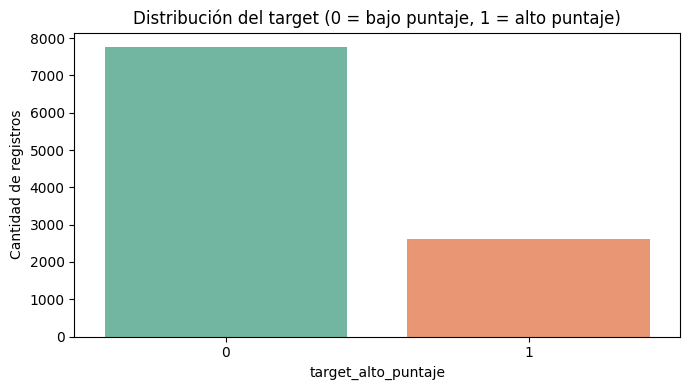

In [25]:
# Paso 4. Exploración visual - Gráfica 1
# Comparación del número de registros por clase del target.
plt.figure(figsize=(7, 4))
sns.countplot(data=model_df, x='target_alto_puntaje', palette='Set2')
plt.title('Distribución del target (0 = bajo puntaje, 1 = alto puntaje)')
plt.xlabel('target_alto_puntaje')
plt.ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

En esta gráfica observamos la proporción entre puntajes altos y no altos según el umbral elegido. Es normal que exista cierto desbalance porque la clase positiva representa los registros ubicados en la parte alta de la distribución de `puntaje`, pero la separación sigue siendo útil para identificar factores asociados a mejor desempeño.

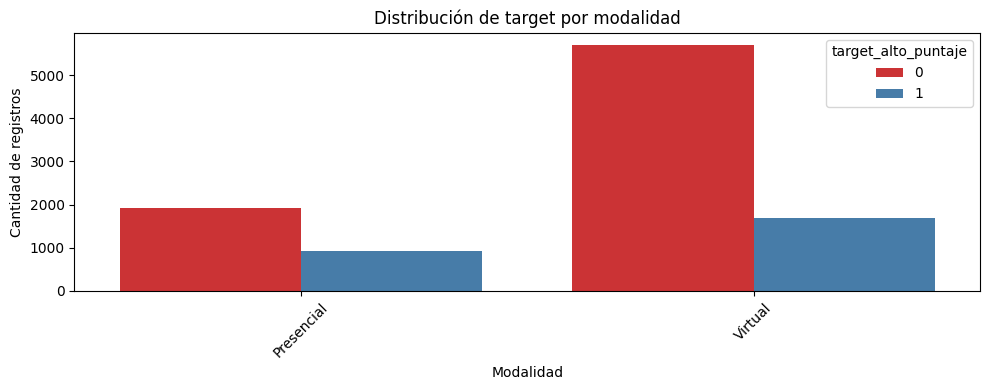

In [26]:
# Paso 4. Exploración visual - Gráfica 2
# Relación entre modalidad y la categoría de puntaje objetivo.
plt.figure(figsize=(10, 4))
sns.countplot(data=model_df, x='modalidad', hue='target_alto_puntaje', palette='Set1')
plt.title('Distribución de target por modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La comparación por `modalidad` permite identificar si existen diferencias visibles en proporción de alto/bajo puntaje entre categorías. Si alguna modalidad concentra mayor porcentaje de clase 1, podría ser una señal útil para el modelo y para decisiones de intervención académica.

In [27]:
# Paso 5. Separar datos en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Tamaño total: {len(X)} registros')
print(f'Entrenamiento: {len(X_train)} registros ({len(X_train)/len(X):.1%})')
print(f'Prueba: {len(X_test)} registros ({len(X_test)/len(X):.1%})')
print('La separación permite entrenar en una parte de los datos y medir generalización en datos no vistos.')

Tamaño total: 10378 registros
Entrenamiento: 8302 registros (80.0%)
Prueba: 2076 registros (20.0%)
La separación permite entrenar en una parte de los datos y medir generalización en datos no vistos.


In [28]:
# Paso 6. Entrenar modelo DecisionTreeClassifier e importancia de variables
modelo_arbol = DecisionTreeClassifier(random_state=42, max_depth=5)
modelo_arbol.fit(X_train, y_train)

# Importancia de variables para interpretar el modelo.
importancias = pd.DataFrame({
    'variable': X_train.columns,
    'importancia': modelo_arbol.feature_importances_
}).sort_values('importancia', ascending=False)

print('Top 10 variables más importantes:')
display(importancias.head(10))
print(f"Variable más importante: {importancias.iloc[0]['variable']}")
print('Esta variable debe interpretarse en el contexto social/académico del problema planteado.')

Top 10 variables más importantes:


,variable,importancia
140,jornada_sin_dato,0.792896
2514,grupo_sin_dato,0.107463
2229,estado_Retirado,0.032553
125,nivel_academico_No registra/No aplica,0.020040
2290,grupo_R6-L1-ATL-AD-B-P-JT-G1,0.013695
132,programa_Arquitectura en la Nube,0.013617
136,programa_Programación,0.004021
2310,grupo_R6-L1-ATL-IA-B-P-JT-G2,0.003877
2269,institucion_sin_dato,0.003699
135,programa_Inteligencia Artificial,0.003331


Variable más importante: jornada_sin_dato
Esta variable debe interpretarse en el contexto social/académico del problema planteado.


In [29]:
# Paso 7. Predicciones y evaluación
y_pred = modelo_arbol.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

resultado_pred = pd.DataFrame({
    'valor_real': y_test.values,
    'prediccion_modelo': y_pred
})

print('Tabla de comparación entre valor real y predicción (primeros 25 registros):')
display(resultado_pred.head(25))

print(f'Accuracy del modelo: {accuracy:.4f} ({accuracy:.2%})')
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, digits=4))
print('Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))

Tabla de comparación entre valor real y predicción (primeros 25 registros):


,valor_real,prediccion_modelo
0,0,0
1,0,0
2,0,0
3,0,1
4,1,0
5,1,0
6,0,0
7,0,1
8,0,0
9,1,0


Accuracy del modelo: 0.8733 (87.33%)
Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.8847    0.9549    0.9184      1551
           1     0.8259    0.6324    0.7163       525

    accuracy                         0.8733      2076
   macro avg     0.8553    0.7936    0.8174      2076
weighted avg     0.8698    0.8733    0.8673      2076

Matriz de confusión:
[[1481   70]
 [ 193  332]]


Interpretación de accuracy: el porcentaje obtenido indica qué proporción de casos del conjunto de prueba fue clasificada correctamente por el árbol de decisión. Entre más alto sea este valor, mejor está aprendiendo el patrón del target, aunque siempre debe revisarse junto con precisión/recall y la matriz de confusión para validar equilibrio entre clases.